In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
from lux.lux import LUX
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from sklearn import svm
from sklearn.metrics import f1_score
from utils import *
from cc_edu import *
from coal_mine_utils import *


## Read coal mine and collect rules for explaination

In [3]:
# ────────────────────────────────────────────────

# Step 1: Load data – keep as DataFrame
dsname="coalmine" 

X_df,y=load_classification_dataset(name=dsname, n_samples=100, n_features=20, n_classes=2)

la = LabelEncoder()
y=la.fit_transform(y)

X_train_df, X_test_df, y_train_real, y_test_real = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

# Step 2: Scale — but keep DataFrame structure
scaler = StandardScaler()
X_train_scaled_df = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)

X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

# Also create NumPy versions only where strictly needed (e.g. UMAP, NearestNeighbors)
X_test_scaled_np = X_test_scaled_df.to_numpy()

# Step 3: Train model (can use scaled DataFrame or NumPy – RandomForest accepts both)
mw = RandomForestClassifier(n_estimators=100, random_state=42)#svm.SVC(probability=True)#RandomForestClassifier(n_estimators=100, random_state=42)
mw.fit(X_train_scaled_df, y_train_real)
print(f"Model Accuracy: {mw.score(X_test_scaled_df, y_test_real):.2f}")

y_test = mw.predict(X_test_scaled_df)
y_train = mw.predict(X_train_scaled_df)

Model Accuracy: 0.88


### Make a plot of the sensors we are using

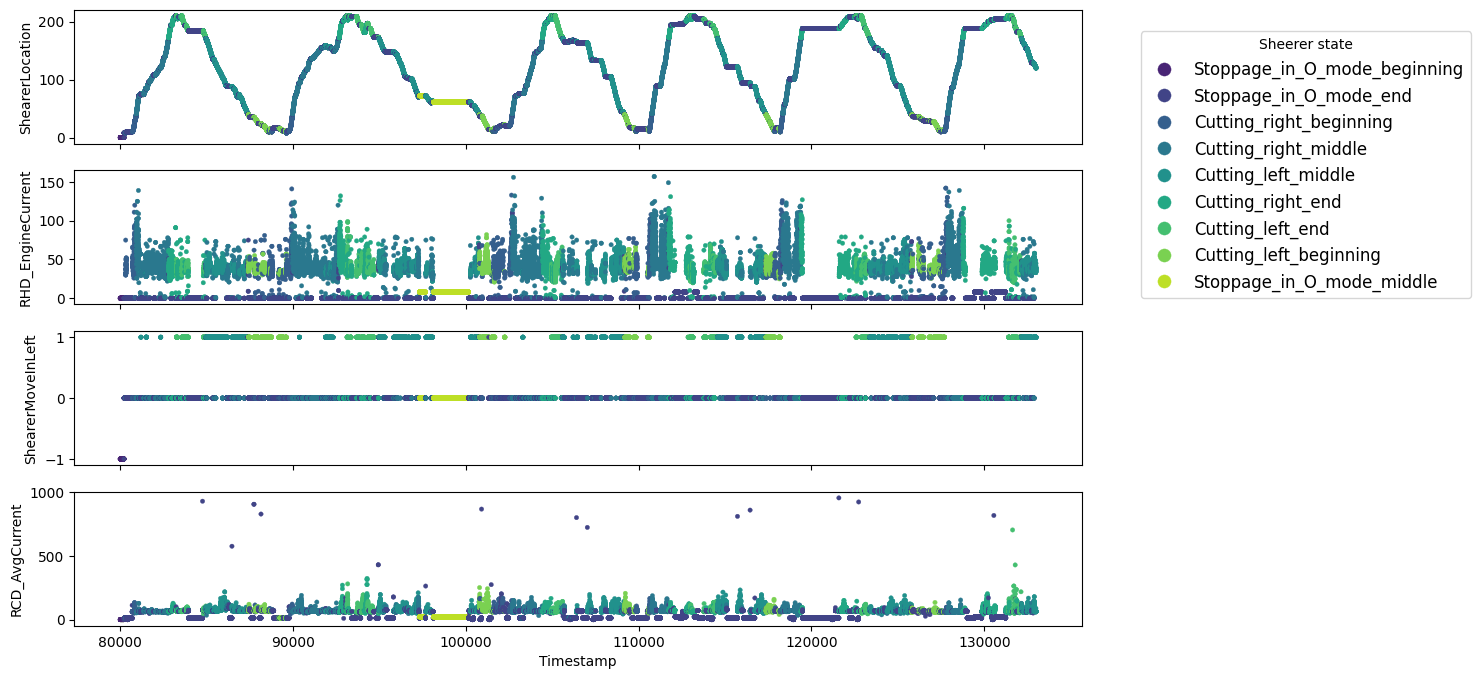

In [109]:
import seaborn as sns

coal=pd.read_csv("https://gitlab.geist.re/pml/x_benchmark-with-selected-datasets/-/raw/main/CDS1/clustering-results-coal-mine-knac.zip")
coal.index.name ='index'
coal.sort_index(inplace=True)

# ---- PLOTTING ----
shplot = coal.iloc[80000:133000]
fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
  

# 4. SM_ShearerLocation
sns.scatterplot(data=shplot, x='index', y='SM_ShearerLocation',
                hue='Expert_clustering', ax=axes[0], palette='viridis', legend=False,s=10, edgecolor=None)
axes[0].set_ylabel("ShearerLocation")

# 2. RHD_EngineCurrent
sns.scatterplot(data=shplot, x='index', y='RHD_EngineCurrent',
             hue='Expert_clustering', ax=axes[1], palette='viridis', legend=False, s=10, edgecolor=None)
axes[1].set_ylabel("RHD_EngineCurrent")

# 3. SM_ShearerMoveInLeft
sns.scatterplot(data=shplot, x='index', y='SM_ShearerMoveInLeft',
             hue='Expert_clustering', ax=axes[2], palette='viridis', legend=False, s=10, edgecolor=None)
axes[2].set_ylabel("ShearerMoveInLeft")


# 4. RCD_AverageThree-phaseCurrent
sns.scatterplot(data=shplot, x='index', y='RCD_AverageThree-phaseCurrent',
             hue='Expert_clustering', ax=axes[3], palette='viridis', s=10, edgecolor=None)
axes[3].set_ylabel("RCD_AvgCurrent")
axes[3].set_xlabel("Timestamp")
# Put legend outside for last subplot
axes[3].legend(title="Sheerer state", bbox_to_anchor=(1.05, 4.5), loc="upper left", markerscale=3,prop={'size': 12})

plt.tight_layout()
plt.savefig("coal-mine-subplots.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Extractu tules from LUX

In [6]:
np.__version__

'1.24.3'

In [7]:
from coal_mine_utils import *

In [8]:
import warnings
warnings.filterwarnings("ignore")

## Note: just a demo here, to test LUX on this case.
cols = list(X_train_scaled_df.columns)
piece_coal = X_test_scaled_df[cols].iloc[0].values.reshape(1,-1)
y_tr_y=mw.predict(X_train_scaled_df)

lux = LUX( predict_proba=mw.predict_proba, 
          classifier=mw,
          neighborhood_size=50,#keep it small as the datset is HUGE 
          max_depth=10,
          oversampling_strategy='importance',
          node_size_limit = 2, grow_confidence_threshold = 0 )
lux.fit(X_train_scaled_df[:1000], y_tr_y[:1000], instance_to_explain=piece_coal, tree_with_shap=False, oblique=True, class_names=list(np.unique(y_tr_y[:1000])))

#see the justification of the instance being classified for a given class
rulelux = lux.justify(piece_coal)

In [9]:
print(rulelux)

['IF SM_ShearerLocation <1.0698771476745605 AND SM_ShearerLocation >=-0.5136433839797974 AND SM_ShearerMoveInLeft >=1.1927502155303955 THEN class = 2 # 1.0\n']


In [10]:
import html
to_remove = []
lux_rules=[]
lux_rule_pred = []
lux_real_pred = []
lux_bbox_pred = []
lux_iloc_indices = []

rules_parsed = []
rules = []



cols=X_train_scaled_df.columns
X_explain = X_train_scaled_df[X_train_scaled_df.columns].copy()
lastlen=0
instancei=0

y_tr_y=mw.predict(X_train_scaled_df)
for i in range(X_train_scaled_df.shape[0]):
    # Remove previously matched instances
    X_explain_df = pd.DataFrame(X_explain.values, columns=cols).drop(index=to_remove)
    if len(X_explain_df) == 0:
        break
    if lastlen == len(X_explain_df):
        print('Nothing was covered, moving to next sample')
        instancei+=1
    else:
        instancei=0
        lastlen=len(X_explain_df)
    if instancei == len(X_explain_df):
        break
        
    print(f'Left to cover {X_explain_df.shape[0]/X_explain.shape[0]*100} %')
    piece_coal = X_explain_df.iloc[instancei].values.reshape(1, -1)

    #lux_real_pred.append( y_real.iloc[instancei])
    lux_bbox_pred.append( mw.predict(piece_coal))

    # Generate Anchor explanation
    lux.fit(X_train_scaled_df, y_tr_y, instance_to_explain=piece_coal, tree_with_shap=False, oblique=True)#,class_names=[0,1,2])

    #see the justification of the instance being classified for a given class
    rulelux = lux.justify(piece_coal)
    
    # Display results
    print('LUX: %s' % (rulelux[0]))

    # Build query and find matching rows

    query = translate_lux_rule_to_query(rulelux[0],X_train_scaled_df.columns)
    lux_rules.append(query)

    justify = lux.justify(piece_coal, to_dict=True)
    rule = parse_lux_rule(justify)
    rules_parsed.append(rule)
    rules.append(justify)
    
    matched_indices = X_explain_df.query(query).index.tolist()

    if len(matched_indices) == 0:
        print('Phantom..')
        lux_rule_pred.append(-1)
        lux_iloc_indices.append(X_explain_df.iloc[[instancei]].index[0])
    else:
        lux_rule_pred.append(lux.predict(piece_coal)[0])
        lux_iloc_indices.append(matched_indices)

    to_remove.extend(matched_indices)


Left to cover 100.0 %
LUX: IF RCD_AverageThree_phaseCurrent <0.35523204505443573 AND RHD_EngineCurrent >=-0.5339974462985992 AND SM_ShearerLocation_discrete >=1.0425544083118439 AND LHD_LeftHaulageDrive_tractor_Temperature_gearbox_ >=0.9625276923179626 AND SM_ShearerMoveInLeft <1.1399120092391968 THEN class = 7 # 1.0

Left to cover 98.315625 %
LUX: IF RCD_AverageThree_phaseCurrent >=-0.2516201436519623 AND RHD_EngineCurrent >=-0.16472697257995605 AND SM_ShearerLocation >=1.0693556070327759 AND SM_ShearerLocation_discrete >=-0.07397673279047012 AND SM_ShearerMoveInLeft <1.7312952280044556 THEN class = 7 # 0.9888888888888889

Left to cover 90.459375 %
LUX: IF LP_AverageThree_phaseCurrent >=0.023699365556240082 AND SM_ShearerLocation <1.0693556070327759 AND SM_ShearerLocation >=-0.5032095611095428 AND SM_ShearerMoveInLeft <1.1399120092391968 THEN class = 5 # 1.0

Left to cover 81.722265625 %
LUX: IF RHD_EngineCurrent <-0.5339974462985992 AND RCD_AverageThree_phaseCurrent <-0.3845467716455

### Save rules for future

In [11]:
ruleset = pd.DataFrame([rules[:10],lux_iloc_indices[:10]]).T.explode(1)
ruleset.columns = ['rule','index']
ruleset.to_csv('ruleset_coal_mine.csv',index=False)
X_test_scaled_df.to_csv('cm_test.csv',index=False)
X_train_scaled_df.to_csv('cmm_train.csv',index=False)

import pickle

# assume mw and lux are trained scikit-learn models
with open("mw.pkl", "wb") as f:
    pickle.dump(mw, f)

with open("lux.pkl", "wb") as f:
    pickle.dump(lux, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("la.pkl", "wb") as f:
    pickle.dump(la, f)

with open("y_train_real.pkl", "wb") as f:
    pickle.dump(y_train_real, f)

with open("y_test_real.pkl", "wb") as f:
    pickle.dump(y_test_real, f)


## Compute metrics (inlcuding CC-EDU)

In [84]:
# expert_rules  = [


#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==1'],
#         'SM_ShearerLocation': ['<40'],
#     }, 'prediction': 'Cutting_left_beginning', 'confidence': 1.0}]],

#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==1'],
#         'SM_ShearerLocation': ['>=40', '<=180'],
#     }, 'prediction': 'Cutting_left_middle', 'confidence': 1.0}]],

#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==1'],
#         'SM_ShearerLocation': ['>=180'],
#     }, 'prediction': 'Cutting_left_end', 'confidence': 1.0}]],

#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==0'],
#         'SM_ShearerLocation': ['<40'],
#     }, 'prediction': 'Cutting_right_beginning', 'confidence': 1.0}]],

#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==0'],
#         'SM_ShearerLocation': ['>=40', '<=180'],
#     }, 'prediction': 'Cutting_right_middle', 'confidence': 1.0}]],

#     [[{'rule': {
#         'RCD_AverageThree_phaseCurrent': ['>0'],
#         'RHD_EngineCurrent': ['>0'],
#         'SM_ShearerMoveInLeft': ['==0'],
#         'SM_ShearerLocation': ['>180'],
#     }, 'prediction': 'Cutting_right_end', 'confidence': 1.0}]],

#     [[{'rule': {
#         'SM_ShearerLocation': ['<40'],
#     }, 'prediction': 'Stoppage_in_O_mode_beginning', 'confidence': 1.0}]],

#     [[{'rule': {
#         'SM_ShearerLocation': ['<180'],
#     }, 'prediction': 'Stoppage_in_O_mode_middle', 'confidence': 1.0}]],

#     [[{'rule': {
#         'SM_ShearerLocation': ['>=180'],
#     }, 'prediction': 'Stoppage_in_O_mode_end', 'confidence': 1.0}]],
# ]

expert_rules = [

    # CUTTING - LEFT
    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==1'],
        'SM_ShearerLocation': ['<40'],
    }, 'prediction': 'Cutting_left_beginning', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==1'],
        'SM_ShearerLocation': ['>=40', '<180'],
    }, 'prediction': 'Cutting_left_middle', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==1'],
        'SM_ShearerLocation': ['>=180'],
    }, 'prediction': 'Cutting_left_end', 'confidence': 1.0}]],


    # CUTTING - RIGHT
    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==0'],
        'SM_ShearerLocation': ['<40'],
    }, 'prediction': 'Cutting_right_beginning', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==0'],
        'SM_ShearerLocation': ['>=40', '<180'],
    }, 'prediction': 'Cutting_right_middle', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['>0'],
        'RHD_EngineCurrent': ['>0'],
        'SM_ShearerMoveInLeft': ['==0'],
        'SM_ShearerLocation': ['>=180'],
    }, 'prediction': 'Cutting_right_end', 'confidence': 1.0}]],


    # STOPPAGE in O-mode (mutually exclusive with cutting via currents <= 0)
    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['<=0'],
        'RHD_EngineCurrent': ['<=0'],
        'SM_ShearerLocation': ['<40'],
    }, 'prediction': 'Stoppage_in_O_mode_beginning', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['<=0'],
        'RHD_EngineCurrent': ['<=0'],
        'SM_ShearerLocation': ['>=40', '<180'],
    }, 'prediction': 'Stoppage_in_O_mode_middle', 'confidence': 1.0}]],

    [[{'rule': {
        'RCD_AverageThree_phaseCurrent': ['<=0'],
        'RHD_EngineCurrent': ['<=0'],
        'SM_ShearerLocation': ['>=180'],
    }, 'prediction': 'Stoppage_in_O_mode_end', 'confidence': 1.0}]],
]

In [85]:
import pickle 
rr = pd.read_csv('ruleset_coal_mine.csv')
X_test_scaled_df = pd.read_csv('cm_test.csv')
X_train_scaled_df = pd.read_csv('cmm_train.csv')

with open("mw.pkl", "rb") as f:
    mw = pickle.load(f)

with open("lux.pkl", "rb") as f:
    lux = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("la.pkl", "rb") as f:
    la = pickle.load(f)

with open("y_train_real.pkl", "rb") as f:
    y_train_real_loaded = pickle.load(f)

with open("y_test_real.pkl", "rb") as f:
    y_test_real_loaded = pickle.load(f)

encoded_exp_rules = encode_rules_with_scaler_and_le(
    expert_rules,   # the rules we produced earlier
    scaler,         # your fitted StandardScaler/MinMaxScaler/etc.
    la,              # your fitted LabelEncoder
    feature_order = list(X_train_scaled_df.columns)
)


In [86]:
OVERLAP_THRESHOLD = 0.001
RESTRICTION_THRESHOLD = 0.001


edu_scores,knni = compute_cc_edu(
        [parse_lux_rule(eval(r)) for r in rr['rule'].unique()]+[parse_lux_rule(r) for r in encoded_exp_rules],
        X_test_scaled_df,
        k=None, #global
        overlap_threshold=OVERLAP_THRESHOLD,
    tqdm=True
    )

Computing CC-EDU: 100%|██████████| 19/19 [00:02<00:00,  7.45it/s]


In [87]:
np.mean(edu_scores)

0.02969840667226482

In [88]:
restricted_rules,_,contradictions = restrict_rules([eval(r) for r in rr['rule'].unique()]+[r for r in encoded_exp_rules],
                                                   X_test_scaled_df, 
                                                   OVERLAP_THRESHOLD,
                                                   RESTRICTION_THRESHOLD,
                                                   k=None,
                                                  tqdm=True)

Restricting rules: 100%|██████████| 19/19 [00:02<00:00,  6.82it/s]


In [89]:
edu_scores_exp,knni = compute_cc_edu(
        [parse_lux_rule(r) for r in restricted_rules],
        X_test_scaled_df,#.iloc[:100000],
        k=None, #global
        overlap_threshold=OVERLAP_THRESHOLD,
    tqdm=True
    )

Computing CC-EDU: 100%|██████████| 19/19 [00:02<00:00,  8.23it/s]


In [90]:
np.mean(edu_scores_exp)

0.009210945562676588

In [91]:
print(f'EDU Drop: {(np.mean(edu_scores)-np.mean(edu_scores_exp))/np.mean(edu_scores)*100}%')

EDU Drop: 68.9850514058768%


In [92]:
y_pred, covered = predict_with_lux_rules(X_test_scaled_df, [eval(r) for r in rr['rule'].unique()]+[r for r in encoded_exp_rules])
y_pred_restricted, covered_restricted = predict_with_lux_rules(X_test_scaled_df, restricted_rules)

In [96]:
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) if p is not None else -1 for p in y_pred ])

f1_before = f1_score(y_test_real_loaded, y_pred, average=avg)

In [97]:
avg='micro'

mask = (covered_restricted > 0) & (y_pred_restricted != None)
y_pred_restricted = np.array([int(p) if p is not None else -1 for p in y_pred_restricted ])

f1_after = f1_score(y_test_real_loaded, y_pred_restricted, average=avg)

In [99]:
print(f'F1 Gain: {(np.mean(f1_after)-np.mean(f1_before))*100}%')

F1 Gain: 15.3109375%
